# Weather Anomaly Agent -- Live Demo

This notebook exercises the core pipeline **against real, live weather data**,
without needing Docker/TimescaleDB/the API/frontend running:

1. Pull live hourly readings straight from Open-Meteo (no API key needed) for
   the three configured stations (`ingestion/config.py`).
2. Run both anomaly detectors (`detection/stl_zscore.py`,
   `detection/seasonal_esd.py`) on the in-memory series -- the same functions
   `detection/run.py` calls, just fed a pandas DataFrame directly instead of
   one read from the `readings` table.
3. Visualize each series with any flagged anomalies overlaid.
4. Inject one synthetic spike so the detectors have something to flag even
   if the real data is currently anomaly-free, purely to illustrate the
   mechanism.
5. Optionally (if `ANTHROPIC_API_KEY` is set), have Claude narrate the
   flagged anomalies -- a simplified, DB-free version of what
   `agent/monitor.py` does with real tool calls in production.

Detection is deterministic/statistical; only the last section touches an
LLM, and only to interpret anomalies already flagged by the engine.

## Setup

In [1]:
import os
import sys
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

REPO_ROOT = os.path.abspath("..")
sys.path.insert(0, REPO_ROOT)                              # for the `ingestion` package
sys.path.insert(0, os.path.join(REPO_ROOT, "detection"))    # detection/*.py import each other as flat modules

load_dotenv(os.path.join(REPO_ROOT, ".env"))

from ingestion.config import STATIONS, VARIABLES
from ingestion.openmeteo import fetch_hourly
from stl_zscore import detect_stl_zscore, METHOD as STL_METHOD
from seasonal_esd import seasonal_hybrid_esd, METHOD as ESD_METHOD
from severity import severity_from_score

FORECAST_URL = "https://api.open-meteo.com/v1/forecast"
PAST_DAYS = 35  # trailing history window; matches detection/run.py's default 30-day window with a little margin

print(f"Live demo run at {datetime.now(timezone.utc).isoformat()}")
STATIONS

Live demo run at 2026-07-19T00:36:45.158551+00:00


[{'id': 'denver-co', 'name': 'Denver, CO', 'lat': 39.7392, 'lon': -104.9903},
 {'id': 'miami-fl', 'name': 'Miami, FL', 'lat': 25.7617, 'lon': -80.1918},
 {'id': 'seattle-wa', 'name': 'Seattle, WA', 'lat': 47.6062, 'lon': -122.3321}]

## 1. Fetch live data from Open-Meteo

`fetch_hourly` is the exact function `ingestion/fetch.py` and
`ingestion/backfill.py` use -- here it's called directly with no database, so
the rows just come back as plain dicts.

In [2]:
rows = []
for station in STATIONS:
    station_rows = fetch_hourly(FORECAST_URL, station, {"past_days": PAST_DAYS, "forecast_days": 1})
    print(f"{station['id']}: {len(station_rows)} readings fetched")
    rows.extend(station_rows)

if not rows:
    raise RuntimeError("No data fetched from Open-Meteo -- check network connectivity.")

readings = pd.DataFrame(rows)
readings["time"] = pd.to_datetime(readings["time"], utc=True)
readings = readings.sort_values("time")
readings.head()

denver-co: 3456 readings fetched


miami-fl: 3456 readings fetched


seattle-wa: 3456 readings fetched


,time,station_id,variable,value,source
0,2026-06-14 00:00:00+00:00,denver-co,temperature_c,26.00,open-meteo
1,2026-06-14 00:00:00+00:00,denver-co,humidity_pct,21.00,open-meteo
2,2026-06-14 00:00:00+00:00,denver-co,wind_speed_ms,4.54,open-meteo
3,2026-06-14 00:00:00+00:00,denver-co,pressure_hpa,846.10,open-meteo
3459,2026-06-14 00:00:00+00:00,miami-fl,pressure_hpa,1015.40,open-meteo


In [3]:
readings.groupby(["station_id", "variable"])["time"].agg(["min", "max", "count"])

min                       max  \
station_id variable                                                            
denver-co  humidity_pct  2026-06-14 00:00:00+00:00 2026-07-19 23:00:00+00:00   
           pressure_hpa  2026-06-14 00:00:00+00:00 2026-07-19 23:00:00+00:00   
           temperature_c 2026-06-14 00:00:00+00:00 2026-07-19 23:00:00+00:00   
           wind_speed_ms 2026-06-14 00:00:00+00:00 2026-07-19 23:00:00+00:00   
miami-fl   humidity_pct  2026-06-14 00:00:00+00:00 2026-07-19 23:00:00+00:00   
           pressure_hpa  2026-06-14 00:00:00+00:00 2026-07-19 23:00:00+00:00   
           temperature_c 2026-06-14 00:00:00+00:00 2026-07-19 23:00:00+00:00   
           wind_speed_ms 2026-06-14 00:00:00+00:00 2026-07-19 23:00:00+00:00   
seattle-wa humidity_pct  2026-06-14 00:00:00+00:00 2026-07-19 23:00:00+00:00   
           pressure_hpa  2026-06-14 00:00:00+00:00 2026-07-19 23:00:00+00:00   
           temperature_c 2026-06-14 00:00:00+00:00 2026-07-19 23:00:00+00:00   
           wind_speed_ms 2026-06-14 00:00:00+00:00 2026-07-19 23:00:00+00:00   

                          count  
station_id variable              
denver-co  humidity_pct     864  
           pressure_hpa     864  
           temperature_c    864  
           wind_speed_ms    864  
miami-fl   humidity_pct     864  
           pressure_hpa     864  
           temperature_c    864  
           wind_speed_ms    864  
seattle-wa humidity_pct     864  
           pressure_hpa     864  
           temperature_c    864  
           wind_speed_ms    864

## 2. Build a regular hourly series per station/variable

STL needs a gap-free, regularly-spaced index. Open-Meteo's hourly data is
normally complete, but we reindex to an explicit hourly range and linearly
interpolate any gap just in case (e.g. the very latest forecast hours not
yet observed).

In [4]:
def build_series(df, station_id, variable):
    subset = df[(df["station_id"] == station_id) & (df["variable"] == variable)]
    series = subset.set_index("time")["value"].sort_index()
    series = series[~series.index.duplicated(keep="last")]
    full_range = pd.date_range(series.index.min(), series.index.max(), freq="h")
    series = series.reindex(full_range)
    if series.isna().any():
        series = series.interpolate(limit_direction="both")
    series.index.name = "time"
    return series

series_by_key = {
    (s["id"], var): build_series(readings, s["id"], var)
    for s in STATIONS
    for var in VARIABLES.values()
}

{k: len(v) for k, v in series_by_key.items()}

{('denver-co', 'temperature_c'): 864,
 ('denver-co', 'humidity_pct'): 864,
 ('denver-co', 'wind_speed_ms'): 864,
 ('denver-co', 'pressure_hpa'): 864,
 ('miami-fl', 'temperature_c'): 864,
 ('miami-fl', 'humidity_pct'): 864,
 ('miami-fl', 'wind_speed_ms'): 864,
 ('miami-fl', 'pressure_hpa'): 864,
 ('seattle-wa', 'temperature_c'): 864,
 ('seattle-wa', 'humidity_pct'): 864,
 ('seattle-wa', 'wind_speed_ms'): 864,
 ('seattle-wa', 'pressure_hpa'): 864}

## 3. Run both detectors over every station/variable pair

Same two functions `detection/run.py` calls per (station, variable) pair
before writing to the `anomalies` table.

In [5]:
all_flagged = []
for (station_id, variable), series in series_by_key.items():
    value_df = pd.DataFrame({"value": series})

    stl_flagged = detect_stl_zscore(value_df)
    if not stl_flagged.empty:
        all_flagged.append(
            stl_flagged.assign(station_id=station_id, variable=variable, method=STL_METHOD).reset_index()
        )

    esd_flagged = seasonal_hybrid_esd(value_df)
    if not esd_flagged.empty:
        all_flagged.append(
            esd_flagged.assign(station_id=station_id, variable=variable, method=ESD_METHOD).reset_index()
        )

if all_flagged:
    anomalies = pd.concat(all_flagged, ignore_index=True)
    anomalies["severity"] = anomalies["score"].apply(severity_from_score)
    anomalies = anomalies[["time", "station_id", "variable", "method", "value", "residual", "score", "severity"]]
    anomalies = anomalies.sort_values("time", ascending=False)
else:
    anomalies = pd.DataFrame(
        columns=["time", "station_id", "variable", "method", "value", "residual", "score", "severity"]
    )

print(f"{len(anomalies)} anomaly-points flagged across {len(series_by_key)} station/variable series "
      f"over the trailing {PAST_DAYS} days.")
anomalies.head(20)

914 anomaly-points flagged across 12 station/variable series over the trailing 35 days.


,time,station_id,variable,method,value,residual,score,severity
403,2026-07-19 18:00:00+00:00,miami-fl,temperature_c,stl_zscore,32.10,4.409748,10.725425,high
415,2026-07-19 18:00:00+00:00,miami-fl,temperature_c,s_h_esd,32.10,4.588489,1.250782,low
802,2026-07-19 16:00:00+00:00,seattle-wa,wind_speed_ms,stl_zscore,2.00,-2.787516,-6.014938,high
688,2026-07-19 12:00:00+00:00,seattle-wa,temperature_c,stl_zscore,12.60,-3.372495,-5.157587,medium
687,2026-07-19 11:00:00+00:00,seattle-wa,temperature_c,stl_zscore,12.90,-3.371900,-5.156673,medium
230,2026-07-19 00:00:00+00:00,denver-co,wind_speed_ms,stl_zscore,5.33,3.281174,4.795464,medium
614,2026-07-18 23:00:00+00:00,miami-fl,pressure_hpa,stl_zscore,1014.90,-1.317015,-4.400165,medium
913,2026-07-18 23:00:00+00:00,seattle-wa,pressure_hpa,stl_zscore,1012.90,2.205962,5.684344,medium
488,2026-07-18 22:00:00+00:00,miami-fl,humidity_pct,stl_zscore,58.00,-13.000521,-4.728517,medium
912,2026-07-18 22:00:00+00:00,seattle-wa,pressure_hpa,stl_zscore,1014.20,3.281506,8.484246,high


### Method comparison: how much do the two detectors agree?

Worth checking explicitly rather than just trusting the combined count above:
STL/z-score flags every point whose *residual* clears a fixed z-score bar,
independently per point, while Seasonal-Hybrid ESD bounds how many points it
can flag at all (`ESD_MAX_ANOMALY_PCT`, default 10% of the series) and tests
them jointly. On a full month of real data where the daily temperature swing
itself widens as summer progresses, STL's fixed period=24 seasonal fit can't
fully absorb that amplitude drift, so it tends to flag many points near each
day's peak/trough as "anomalous" -- not necessarily wrong, but much noisier
than S-H-ESD's more conservative count. Seeing both side by side is more
informative than either alone.

In [6]:
method_counts = (
    anomalies.groupby(["station_id", "variable", "method"]).size().unstack(fill_value=0)
    if not anomalies.empty
    else pd.DataFrame()
)
method_counts

method                    s_h_esd  stl_zscore
station_id variable                          
denver-co  humidity_pct         0          88
           pressure_hpa         0         103
           temperature_c        0          75
           wind_speed_ms        5          68
miami-fl   humidity_pct         4          73
           pressure_hpa         0          31
           temperature_c       12          65
           wind_speed_ms        4          87
seattle-wa humidity_pct         0          68
           pressure_hpa         0         103
           temperature_c        0          74
           wind_speed_ms        8          46

## 4. Visualize

Temperature is always plotted for every station as a baseline; any other
variable with a live flagged anomaly right now gets its own plot too.

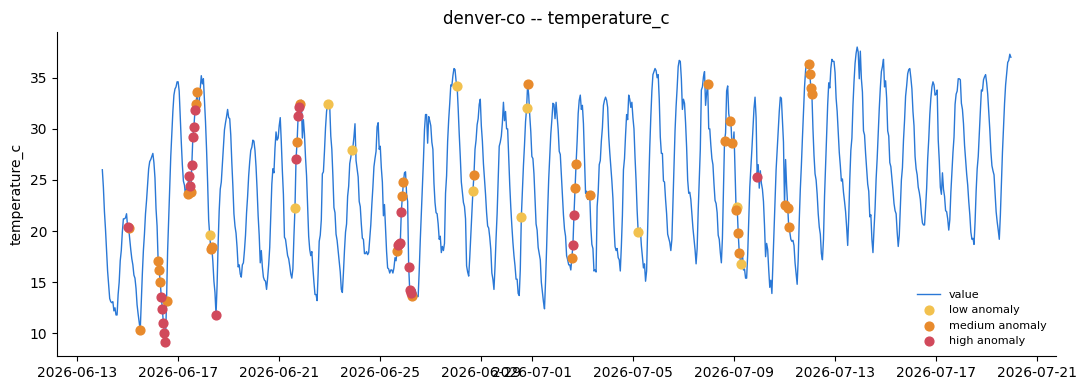

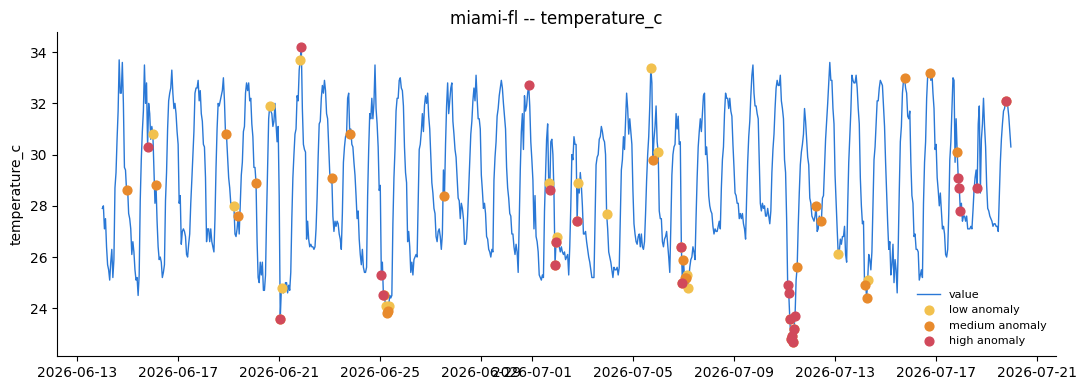

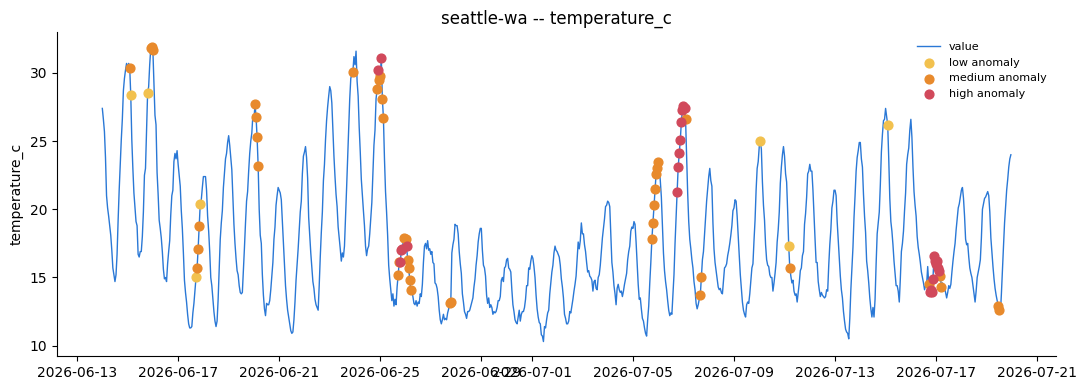

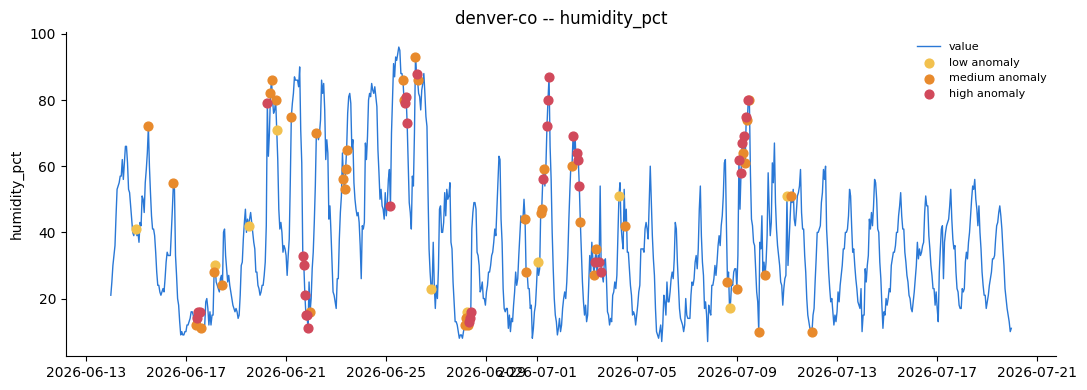

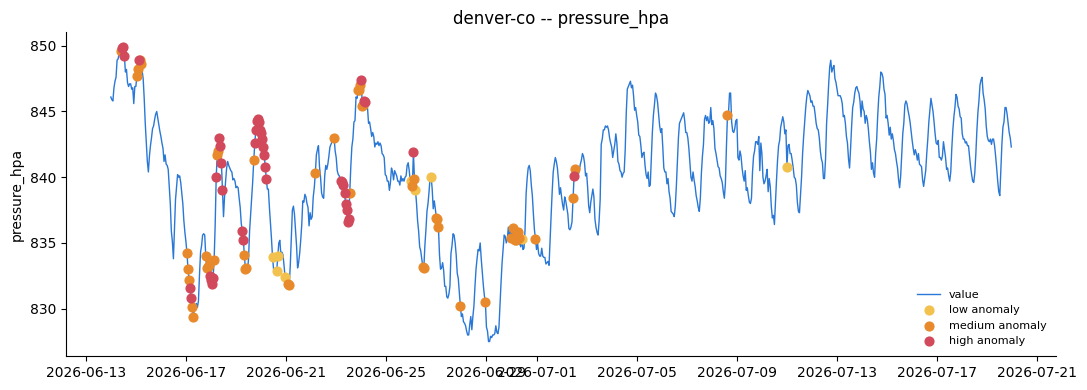

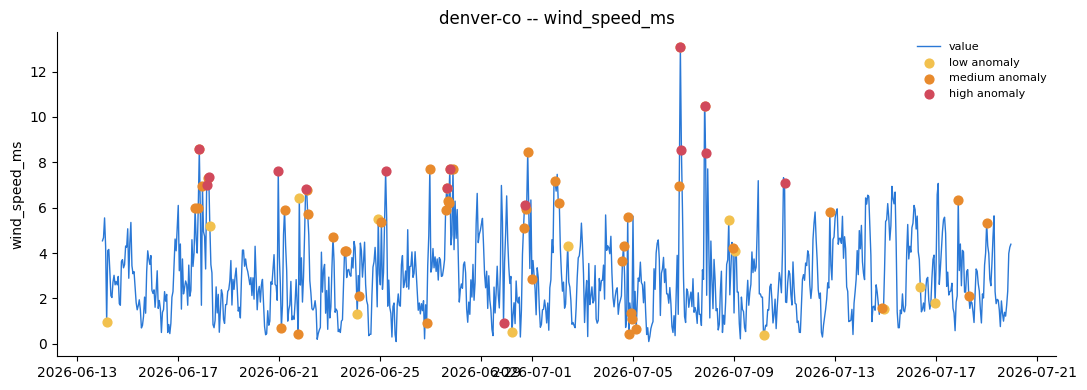

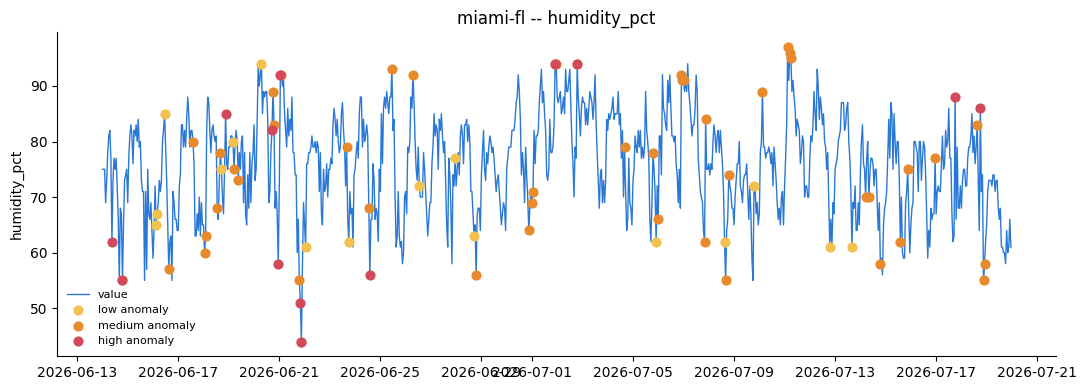

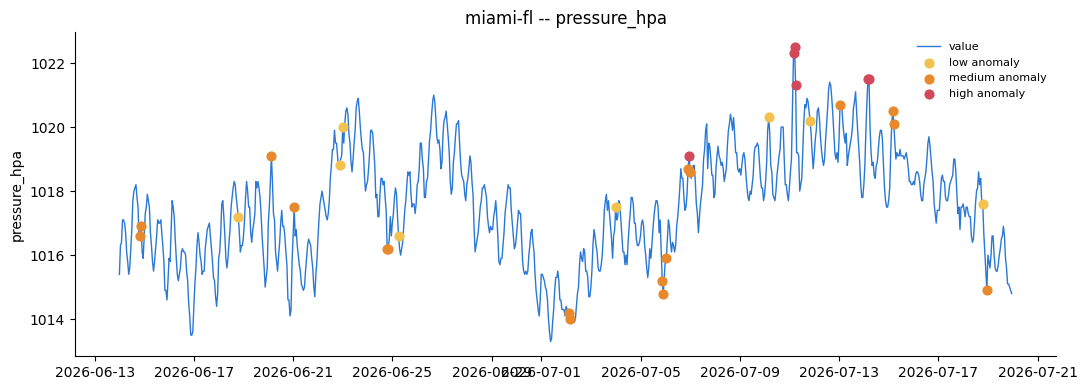

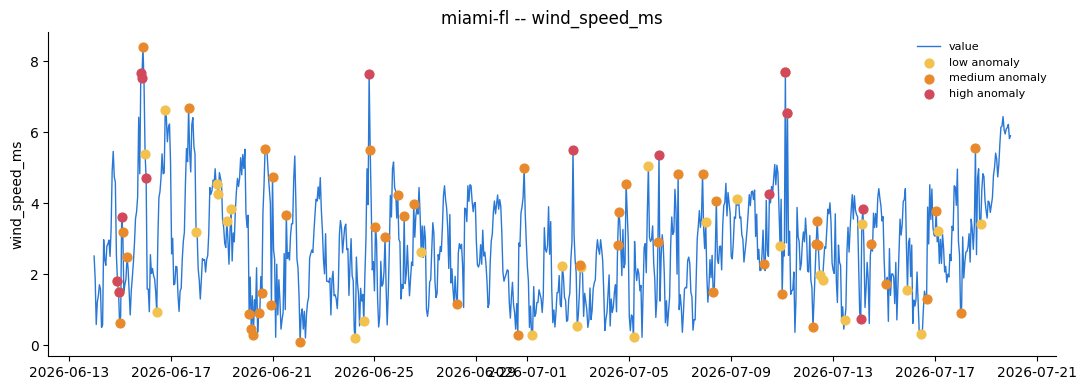

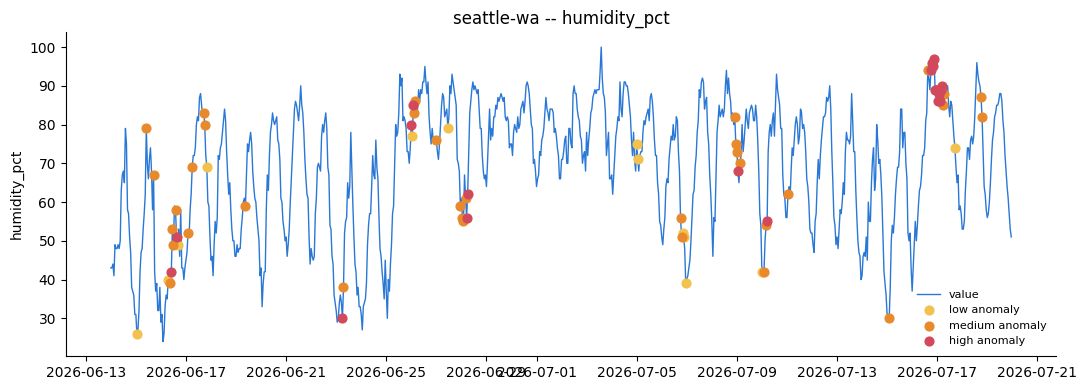

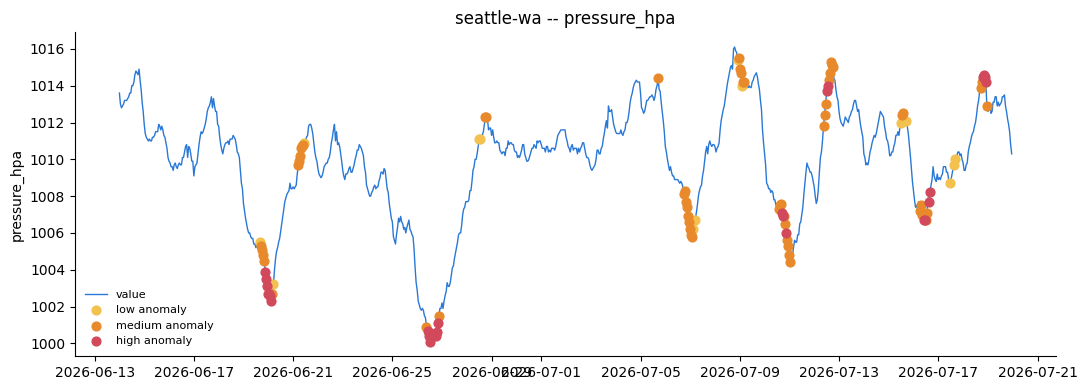

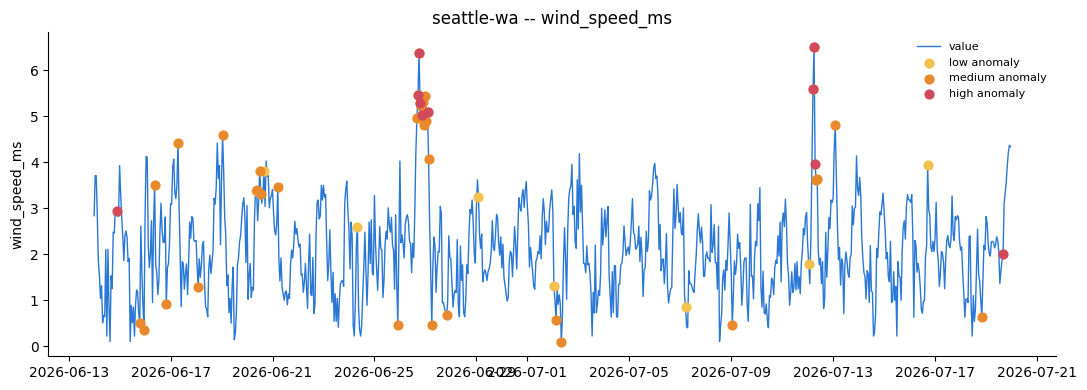

In [7]:
SEVERITY_COLORS = {"low": "#f2c14e", "medium": "#e88a2c", "high": "#d1495b"}

def plot_series_with_anomalies(station_id, variable, series, flagged, title_suffix=""):
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(series.index, series.values, color="#2a78d6", linewidth=1, label="value")
    for severity, color in SEVERITY_COLORS.items():
        pts = flagged[flagged["severity"] == severity] if "severity" in flagged else flagged
        if not pts.empty:
            ax.scatter(pts["time"], pts["value"], color=color, zorder=5, label=f"{severity} anomaly", s=40)
    ax.set_title(f"{station_id} -- {variable}{title_suffix}")
    ax.set_ylabel(variable)
    ax.legend(frameon=False, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

keys_to_plot = [(s["id"], "temperature_c") for s in STATIONS]
extra_keys = sorted(set(zip(anomalies["station_id"], anomalies["variable"])) - set(keys_to_plot))
keys_to_plot += extra_keys

for station_id, variable in keys_to_plot:
    series = series_by_key[(station_id, variable)]
    flagged_here = anomalies[(anomalies["station_id"] == station_id) & (anomalies["variable"] == variable)]
    plot_series_with_anomalies(station_id, variable, series, flagged_here)

## 5. Illustrative example: what a flagged anomaly looks like

Live conditions may currently be unremarkable everywhere (that's the
detectors working correctly, not a bug). To show the mechanism concretely,
this cell injects one obviously-anomalous synthetic spike into a copy of a
real series -- clearly separate from the live analysis above.

In [8]:
demo_key = (STATIONS[0]["id"], "temperature_c")
demo_series = series_by_key[demo_key].copy()

spike_time = demo_series.index[-6]
demo_series.loc[spike_time] += 18  # synthetic +18C spike, illustration only

demo_df = pd.DataFrame({"value": demo_series})
demo_stl_flagged = detect_stl_zscore(demo_df)
demo_esd_flagged = seasonal_hybrid_esd(demo_df)

print("STL/z-score flagged:")
print(demo_stl_flagged)
print("\nSeasonal-Hybrid ESD flagged:")
print(demo_esd_flagged)

STL/z-score flagged:
                           value   residual      score
time                                                  
2026-06-15 00:00:00+00:00   20.4  -5.204968  -6.265702
2026-06-15 01:00:00+00:00   20.3  -3.862959  -4.648388
2026-06-16 05:00:00+00:00   17.1  -3.629214  -4.366691
2026-06-16 06:00:00+00:00   16.2  -4.047717  -4.871048
2026-06-16 07:00:00+00:00   15.0  -4.664482  -5.614339
...                          ...        ...        ...
2026-07-11 23:00:00+00:00   36.3   4.414297   5.326904
2026-07-12 00:00:00+00:00   35.4   3.900401   4.707585
2026-07-12 01:00:00+00:00   34.0   3.428874   4.139326
2026-07-12 02:00:00+00:00   33.4   4.481093   5.407403
2026-07-19 18:00:00+00:00   52.3  18.352816  22.124836

[75 rows x 3 columns]

Seasonal-Hybrid ESD flagged:
                           value   residual     score
time                                                 
2026-07-19 18:00:00+00:00   52.3  23.046145  1.657571


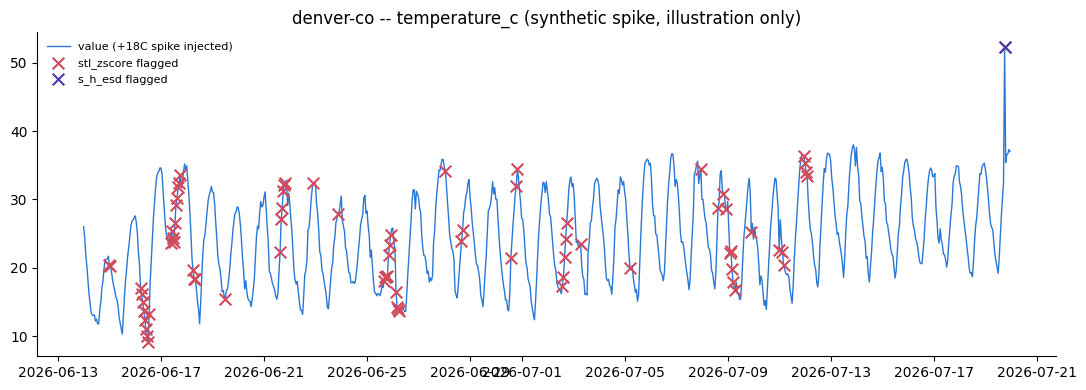

In [9]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(demo_series.index, demo_series.values, color="#2a78d6", linewidth=1, label="value (+18C spike injected)")
for flagged_df, color, label in [
    (demo_stl_flagged, "#d1495b", "stl_zscore flagged"),
    (demo_esd_flagged, "#4a3aa7", "s_h_esd flagged"),
]:
    if not flagged_df.empty:
        ax.scatter(flagged_df.index, flagged_df["value"], color=color, zorder=5, label=label, s=70, marker="x")
ax.set_title(f"{demo_key[0]} -- {demo_key[1]} (synthetic spike, illustration only)")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Agent narration (optional -- requires `ANTHROPIC_API_KEY`)

`agent/monitor.py` investigates each anomaly with a tool-using Claude agent
that queries the database for surrounding context. This notebook has no
database, so instead we hand Claude the already-computed context directly in
the prompt and ask for the same kind of narrative judgment -- a simplified,
read-only stand-in for the real tool loop.

If `ANTHROPIC_API_KEY` isn't set, this cell explains that and skips, rather
than failing -- matching the caveat in the root README that this is the one
piece not run against a real key during development.

In [10]:
ANTHROPIC_MODEL = os.environ.get("CHAT_MODEL", "claude-opus-4-8")

SYSTEM_PROMPT = """You are a weather anomaly investigation agent. You are given anomalies
already flagged by a statistical detection engine (STL decomposition + robust z-score,
and Seasonal-Hybrid ESD) -- you do not need to re-derive whether they are numerically
unusual, that part is done.

For each anomaly, briefly say whether it looks like a real, alert-worthy weather event
or likely noise, and why, citing only the numbers given to you. Be concise."""

if os.environ.get("ANTHROPIC_API_KEY"):
    import anthropic

    context_anomalies = anomalies.head(10).to_dict("records")
    if not context_anomalies:
        # Nothing live to narrate -- fall back to the synthetic illustration above.
        context_anomalies = [
            {**row, "station_id": demo_key[0], "variable": demo_key[1], "method": STL_METHOD}
            for row in demo_stl_flagged.reset_index().to_dict("records")
        ]

    client = anthropic.Anthropic()
    message = client.messages.create(
        model=ANTHROPIC_MODEL,
        max_tokens=1024,
        system=SYSTEM_PROMPT,
        messages=[{"role": "user", "content": f"Anomalies detected:\n{context_anomalies}"}],
    )
    for block in message.content:
        if block.type == "text":
            print(block.text)
else:
    print(
        "ANTHROPIC_API_KEY not set -- skipping live agent narration.\n"
        "Set it in .env to see agent/monitor.py-style narration of the anomalies above.\n"
        "(The full agent also calls tools to pull climatology and related anomalies from "
        "the DB; here we pass the already-computed context directly since this notebook "
        "has no database.)"
    )

ANTHROPIC_API_KEY not set -- skipping live agent narration.
Set it in .env to see agent/monitor.py-style narration of the anomalies above.
(The full agent also calls tools to pull climatology and related anomalies from the DB; here we pass the already-computed context directly since this notebook has no database.)


## Notes

What this notebook does **not** cover, by design (kept dependency-free and
DB-free for a quick live demo):

- TimescaleDB / the `readings` and `anomalies` tables -- everything above
  runs on in-memory pandas DataFrames instead.
- Climatology comparison (`compare_to_climatology`) -- that needs years of
  backfilled history in the DB; this notebook only pulls the last
  `PAST_DAYS` days.
- The FastAPI layer and the React dashboard.
- The full tool-using agent loop (`agent/monitor.py`, `agent/report.py`) --
  section 6 above calls Claude directly with precomputed context instead of
  letting it query the DB itself.

See the root `README.md` for the full Docker/TimescaleDB end-to-end path,
including the live `/chat` endpoint and dashboard.